In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks')

## **Data Pre-processing & Model Development**

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from glob import glob
import cv2
import albumentations as A
import numpy as np
from tqdm import tqdm

from torch.utils.data import DataLoader
from dataset import BrainTumorDataset

import torch
import torch.nn as nn
from unet import UNet


plt.style.use("ggplot")
%matplotlib inline

In [3]:
# Setting Size Parameters of images
img_width = 256
img_height = 256

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

# Image loading
image_filenames = []

mask_files = glob(f'{path}/kaggle_3m/*/*_mask*')

for i in mask_files:
    image_filenames.append(i.replace("_mask", ""))

print(image_filenames[:10])
len(image_filenames)

In [4]:
# Image loading
image_filenames = []

mask_files = glob('./Dataset/kaggle_3m/*/*_mask*')

for i in mask_files:
    image_filenames.append(i.replace("_mask", ""))

print(image_filenames[:10])
len(image_filenames)

['./Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_10.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_11.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_12.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_13.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_14.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_15.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_16.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_17.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_18.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_19.tif']


3929

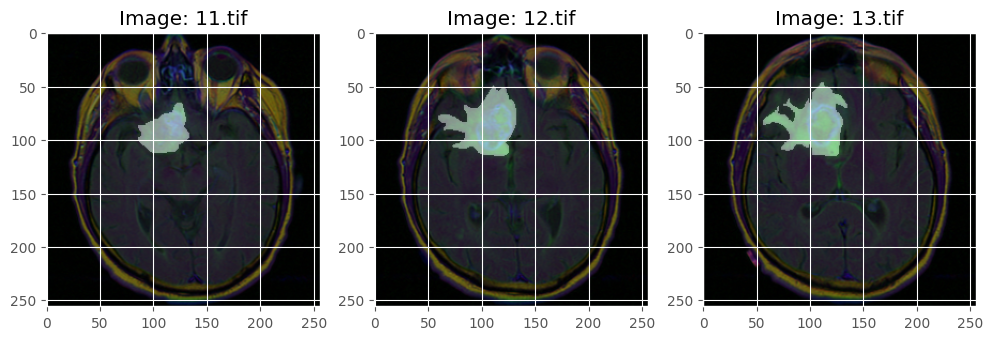

In [5]:
# sample plot of images and masks
def plot_from_img_path(rows, columns, list_img_path, list_mask_path):
    fig = plt.figure(figsize=(12, 12))
    for i in range(1, rows * columns + 1):
        fig.add_subplot(rows, columns, i)
        img_path = list_img_path[i]
        mask_path = list_mask_path[i]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        plt.title(f"Image: {img_path.split('/')[-1][-6:]}")
        plt.imshow(image)
        plt.imshow(mask, alpha=0.4)
    plt.show()
    
plot_from_img_path(1,3, image_filenames, mask_files)

In [6]:
# Dataframe creation
df = pd.DataFrame(data={'image_filenames': image_filenames, "mask" : mask_files})
df.shape

(3929, 2)

In [7]:
# Splitting the Dataset

df_train, df_test = train_test_split(df, test_size=0.05) # Test Size - 0.1 means 10%
df_train, df_val = train_test_split(df_train, test_size=0.2)

print(df_train.shape)
print(df_test.shape)
print(df_val.shape)

(2985, 2)
(197, 2)
(747, 2)


In [8]:
# Image Augmentation Parameters
train_transform = A.Compose([
    A.Rotate(limit=20, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=0, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Resize(256, 256),
    A.Normalize(mean=(0, 0, 0), std=(1, 1, 1))
])

test_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0, 0, 0), std=(1, 1, 1))
])

/usr/local/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
BATCH_SIZE = 32

train_image_paths = df_train["image_filenames"].values
train_mask_paths = df_train["mask"].values
val_image_paths = df_val["image_filenames"].values
val_mask_paths = df_val["mask"].values
test_image_paths = df_test["image_filenames"].values
test_mask_paths = df_test["mask"].values

train_dataset = BrainTumorDataset(train_image_paths, train_mask_paths, transform=train_transform)
val_dataset = BrainTumorDataset(val_image_paths, val_mask_paths, transform=test_transform)
test_dataset = BrainTumorDataset(test_image_paths, test_mask_paths, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


# Example: one batch
images, masks = next(train_loader.__iter__())
print(images.shape, masks.shape)


torch.Size([32, 3, 256, 256]) torch.Size([32, 1, 256, 256])


## **Model Trainning**

In [9]:
# Evaluation Metrics
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_flat = y_true.view(-1)
    y_pred_flat = y_pred.view(-1)
    
    intersection = (y_true_flat * y_pred_flat).sum()
    union = y_true_flat.sum() + y_pred_flat.sum()
    
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou(y_true, y_pred, smooth=1e-6):
    y_true_flat = y_true.view(-1)
    y_pred_flat = y_pred.view(-1)
    
    intersection = (y_true_flat * y_pred_flat).sum()
    total = (y_true_flat + y_pred_flat).sum()
    
    union = total - intersection
    return (intersection + smooth) / (union + smooth)

# def jaccard_distance(y_true, y_pred, smooth=1e-6):
#     return 1 - iou(y_true, y_pred, smooth)



In [ ]:
EPOCHS = 50
learning_rate = 1e-4
device = "cpu"

def binary_accuracy(y_true, y_pred):
    preds = (y_pred > 0.5).float()
    return (preds == y_true).float().mean()

def train_unet(model, train_loader, val_loader, num_epochs=EPOCHS, lr=learning_rate, device="cuda"):
    criterion_bce = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=learning_rate / EPOCHS)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda epoch: 1 - epoch/EPOCHS)

    best_val_loss = float("inf")

    history = {
        "train_loss": [], "val_loss": [],
        "train_dice": [], "val_dice": [],
        "train_iou": [], "val_iou": [],
        "train_acc": [], "val_acc": []  # NEW
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ---- TRAINING ----
        model.train()
        train_loss, train_dice, train_iou, train_acc = 0, 0, 0, 0

        train_bar = tqdm(train_loader, desc="Training", leave=False)
        for imgs, masks in train_bar:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)

            bce = criterion_bce(outputs, masks)
            dice = dice_loss(masks, outputs)
            loss = 0.1 * bce + 0.9 * dice

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Metrics
            train_loss += loss.item()
            train_dice += dice_coefficient(masks, outputs).item()
            train_iou += iou(masks, outputs).item()
            train_acc += binary_accuracy(masks, outputs).item()  # NEW

            train_bar.set_postfix(loss=loss.item())

        avg_train_loss = train_loss / len(train_loader)
        avg_train_dice = train_dice / len(train_loader)
        avg_train_iou = train_iou / len(train_loader)
        avg_train_acc = train_acc / len(train_loader)  # NEW

        # ---- VALIDATION ----
        model.eval()
        val_loss, val_dice, val_iou, val_acc = 0, 0, 0, 0

        val_bar = tqdm(val_loader, desc="Validation", leave=False)
        with torch.no_grad():
            for imgs, masks in val_bar:
                imgs, masks = imgs.to(device), masks.to(device)
                outputs = model(imgs)

                bce = criterion_bce(outputs, masks)
                dice = dice_loss(masks, outputs)
                loss = 0.1 * bce + 0.9 * dice

                # Metrics
                val_loss += loss.item()
                val_dice += dice_coefficient(masks, outputs).item()
                val_iou += iou(masks, outputs).item()
                val_acc += binary_accuracy(masks, outputs).item()  # NEW

                val_bar.set_postfix(loss=loss.item())

        avg_val_loss = val_loss / len(val_loader)
        avg_val_dice = val_dice / len(val_loader)
        avg_val_iou = val_iou / len(val_loader)
        avg_val_acc = val_acc / len(val_loader)  # NEW

        # Store history
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_dice"].append(avg_train_dice)
        history["val_dice"].append(avg_val_dice)
        history["train_iou"].append(avg_train_iou)
        history["val_iou"].append(avg_val_iou)
        history["train_acc"].append(avg_train_acc)
        history["val_acc"].append(avg_val_acc)

        scheduler.step()

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} "
              f"| Dice: {avg_val_dice:.4f} | IoU: {avg_val_iou:.4f} | Acc: {avg_val_acc:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "/content/drive/MyDrive/Colab Notebooks/best_unet.pth")
            # torch.save(model.state_dict(), "best_unet.pth")
            print("Saved best model")

    return model, history


In [ ]:
# Train model
model = UNet().to(device)
model, history = train_unet(model, train_loader, val_loader, num_epochs=EPOCHS, lr=learning_rate, device=device)



Epoch 1/50


Epoch [1/50] Train Loss: 0.6392 | Val Loss: 0.7249 | Dice: 0.0183 | IoU: 0.0092
Saved best model

Epoch 2/50


Epoch [2/50] Train Loss: 0.5742 | Val Loss: 0.6910 | Dice: 0.0191 | IoU: 0.0097
Saved best model

Epoch 3/50


Epoch [3/50] Train Loss: 0.5425 | Val Loss: 0.5788 | Dice: 0.0200 | IoU: 0.0101
Saved best model

Epoch 4/50


Epoch [4/50] Train Loss: 0.5155 | Val Loss: 0.5748 | Dice: 0.0183 | IoU: 0.0093
Saved best model

Epoch 5/50


...

Epoch [10/50] Train Loss: 0.3370 | Val Loss: 0.5212 | Dice: 0.0108 | IoU: 0.0054
Saved best model

Epoch 11/50


Epoch [11/50] Train Loss: 0.2982 | Val Loss: 0.5198 | Dice: 0.0130 | IoU: 0.0066
Saved best model

Epoch 12/50


Epoch [12/50] Train Loss: 0.2687 | Val Loss: 0.5391 | Dice: 0.0007 | IoU: 0.0004

Epoch 13/50


Epoch [13/50] Train Loss: 0.2377 | Val Loss: 0.5535 | Dice: 0.0000 | IoU: 0.0000

Epoch 14/50


Training:  81%|████████  | 76/94 [35:24<07:47, 25.98s/it, loss=0.243]

In [ ]:
# Step 1: Load previous model
model = UNet()
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/best_unet.pth"))
model.to(device)

# Step 2: Continue training
model, history = train_unet(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=30,
    lr=learning_rate,
    device=device
)

In [ ]:

# --- Plot Loss ---
plt.figure(figsize=(10,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# --- Plot Dice Score ---
plt.figure(figsize=(10,5))
plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Validation Dice")
plt.xlabel("Epochs")
plt.ylabel("Dice Coefficient")
plt.title("Training vs Validation Dice Score")
plt.legend()
plt.show()

# --- Plot IoU ---
plt.figure(figsize=(10,5))
plt.plot(history["train_iou"], label="Train IoU")
plt.plot(history["val_iou"], label="Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("Training vs Validation IoU")
plt.legend()
plt.show()

# --- Plot Binary Accuracy ---
plt.figure(figsize=(10,5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Binary Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


   Epoch  Train Loss  Val Loss    Dice     IoU
0      1      0.6651    0.6829  0.0235  0.0119
1      2      0.5986    0.6909  0.0236  0.0119
2      3      0.5702    0.5916  0.0196  0.0099
3      4      0.5443    0.7114  0.0268  0.0136
4      5      0.5233    0.5810  0.0151  0.0076
5      6      0.5013    0.5780  0.0187  0.0095
6      7      0.4766    0.5543  0.0209  0.0106
7      8      0.4523    0.5576  0.0226  0.0114
8      9      0.4229    0.5594  0.0167  0.0084
9     10      0.3937    0.5514  0.0244  0.0124
    Epoch  Train Loss  Val Loss    Dice     IoU
40     41      0.0705    0.0747  0.8633  0.7609
41     42      0.0673    0.3793  0.3060  0.1915
42     43      0.0678    0.1565  0.7182  0.5666
43     44      0.0675    0.0703  0.8708  0.7727
44     45      0.0654    0.0657  0.8800  0.7871
45     46      0.0652    0.1440  0.7428  0.5966
46     47      0.0688    0.2112  0.6173  0.4571
47     48      0.0654    0.0850  0.8455  0.7341
48     49      0.0638    0.0674  0.8773  0.7831
49 

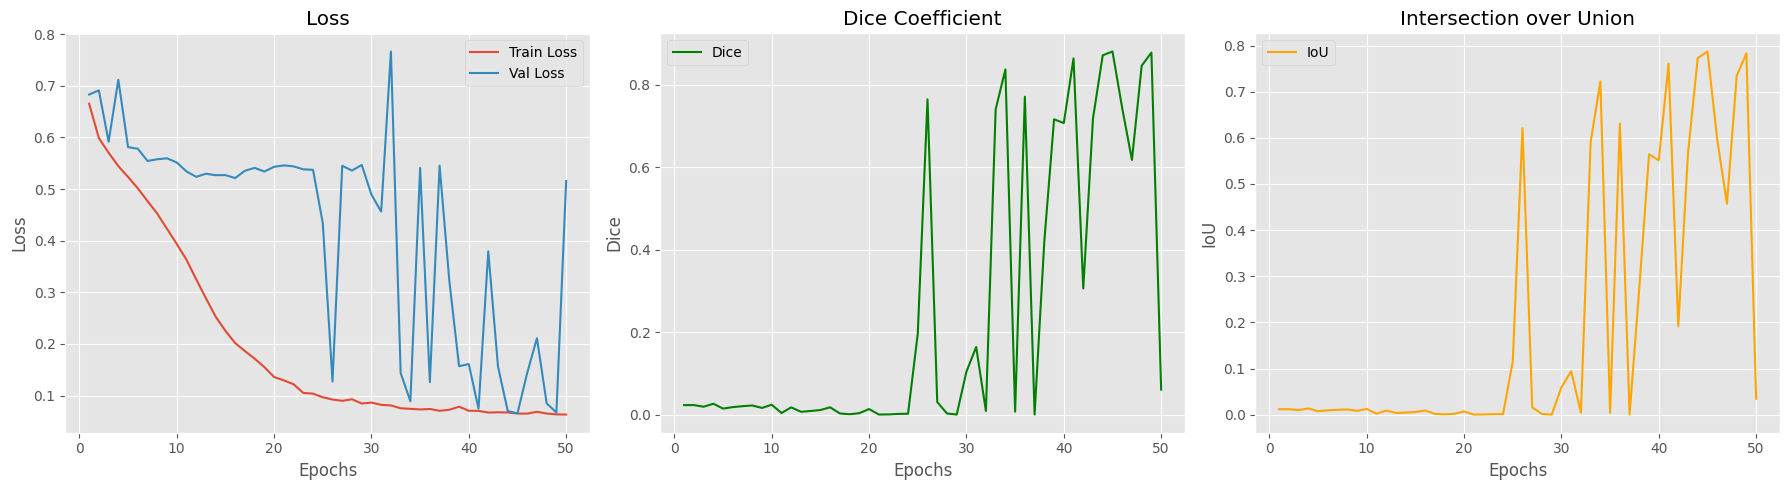

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
data = {
    "Epoch": list(range(1, 51)),
    "Train Loss": [0.6651,0.5986,0.5702,0.5443,0.5233,0.5013,0.4766,0.4523,0.4229,0.3937,
                   0.3631,0.3253,0.2885,0.2528,0.2255,0.2019,0.1864,0.1716,0.1553,0.1361,
                   0.1296,0.1221,0.1053,0.1039,0.0969,0.0925,0.0900,0.0930,0.0848,0.0866,
                   0.0822,0.0811,0.0756,0.0745,0.0733,0.0742,0.0707,0.0727,0.0786,0.0708,
                   0.0705,0.0673,0.0678,0.0675,0.0654,0.0652,0.0688,0.0654,0.0638,0.0634],
    "Val Loss": [0.6829,0.6909,0.5916,0.7114,0.5810,0.5780,0.5543,0.5576,0.5594,0.5514,
                 0.5340,0.5236,0.5295,0.5268,0.5269,0.5212,0.5353,0.5409,0.5338,0.5430,
                 0.5457,0.5438,0.5381,0.5372,0.4341,0.1274,0.5450,0.5357,0.5466,0.4892,
                 0.4562,0.7662,0.1439,0.0892,0.5407,0.1263,0.5453,0.3224,0.1571,0.1611,
                 0.0747,0.3793,0.1565,0.0703,0.0657,0.1440,0.2112,0.0850,0.0674,0.5153],
    "Dice": [0.0235,0.0236,0.0196,0.0268,0.0151,0.0187,0.0209,0.0226,0.0167,0.0244,
             0.0044,0.0180,0.0073,0.0093,0.0116,0.0182,0.0033,0.0014,0.0040,0.0140,
             0.0007,0.0009,0.0022,0.0026,0.1966,0.7639,0.0309,0.0033,0.0006,0.1047,
             0.1643,0.0093,0.7395,0.8365,0.0076,0.7704,0.0007,0.4205,0.7158,0.7066,
             0.8633,0.3060,0.7182,0.8708,0.8800,0.7428,0.6173,0.8455,0.8773,0.0611],
    "IoU": [0.0119,0.0119,0.0099,0.0136,0.0076,0.0095,0.0106,0.0114,0.0084,0.0124,
            0.0022,0.0091,0.0037,0.0047,0.0059,0.0092,0.0017,0.0007,0.0020,0.0071,
            0.0003,0.0005,0.0011,0.0013,0.1153,0.6211,0.0159,0.0016,0.0003,0.0593,
            0.0946,0.0047,0.5913,0.7220,0.0041,0.6309,0.0004,0.2756,0.5642,0.5513,
            0.7609,0.1915,0.5666,0.7727,0.7871,0.5966,0.4571,0.7341,0.7831,0.0345]
}

df = pd.DataFrame(data)

# Display first 10 and last 10 rows for quick analysis
print(df.head(10))
print(df.tail(10))

# Plot all metrics together
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axs[0].plot(df["Epoch"], df["Train Loss"], label="Train Loss")
axs[0].plot(df["Epoch"], df["Val Loss"], label="Val Loss")
axs[0].set_title("Loss")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

# Dice
axs[1].plot(df["Epoch"], df["Dice"], label="Dice", color='green')
axs[1].set_title("Dice Coefficient")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Dice")
axs[1].legend()

# IoU
axs[2].plot(df["Epoch"], df["IoU"], label="IoU", color='orange')
axs[2].set_title("Intersection over Union")
axs[2].set_xlabel("Epochs")
axs[2].set_ylabel("IoU")
axs[2].legend()

plt.tight_layout()
plt.show()


## **Inferencing using the Model**

/tmp/ipykernel_724/3619054719.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_unet.pth", map_location=device))


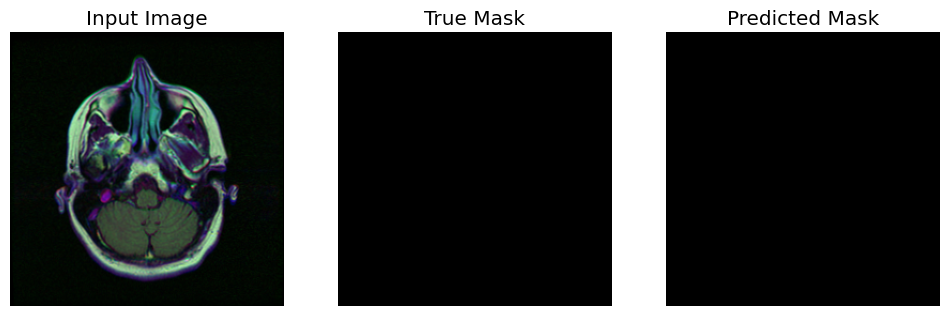

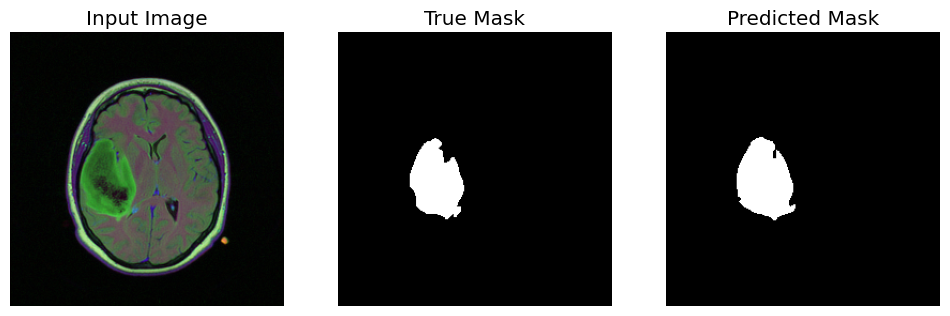

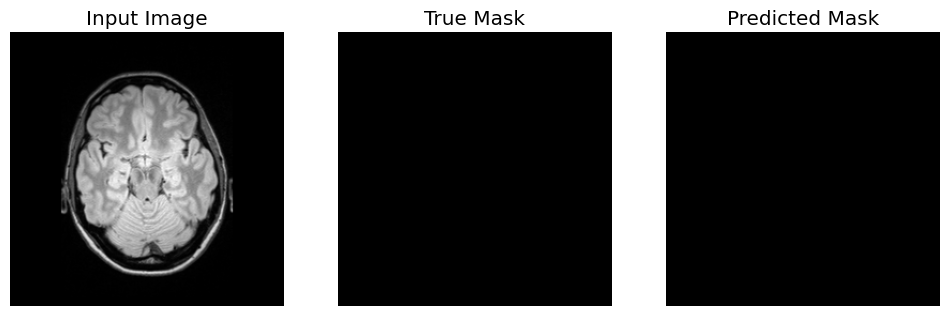

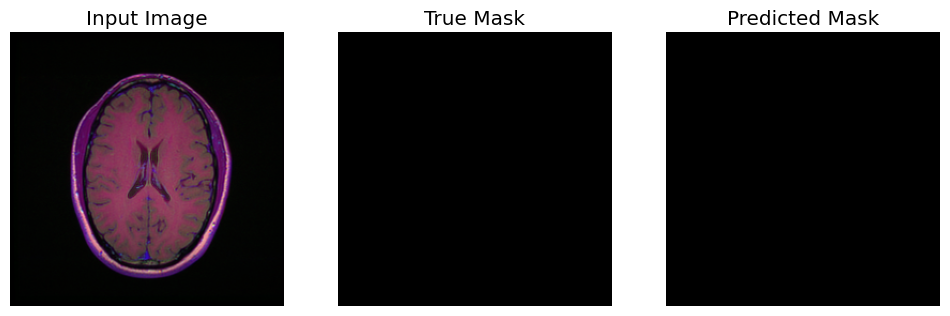

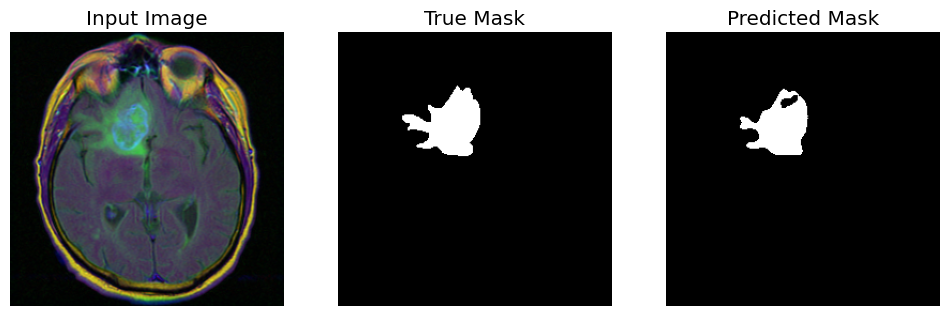

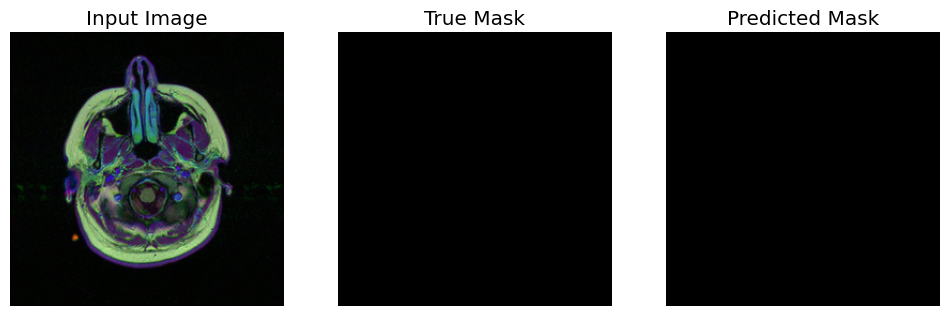

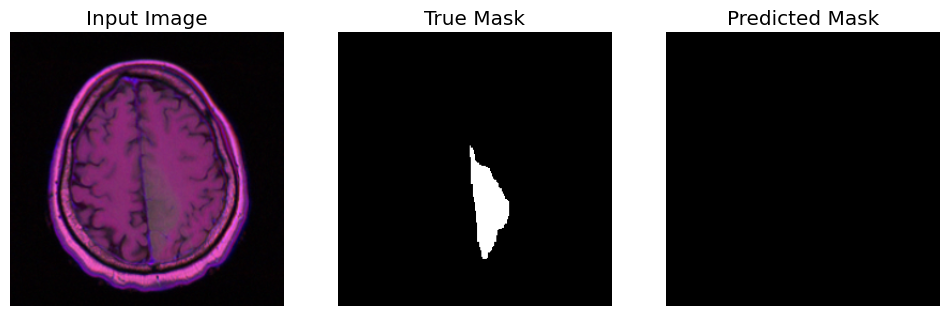

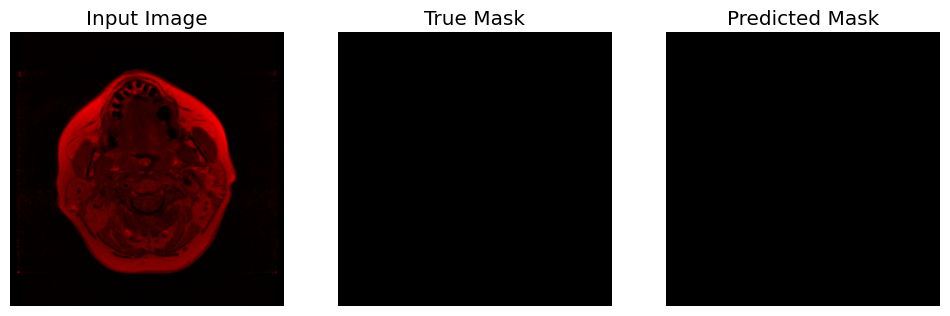

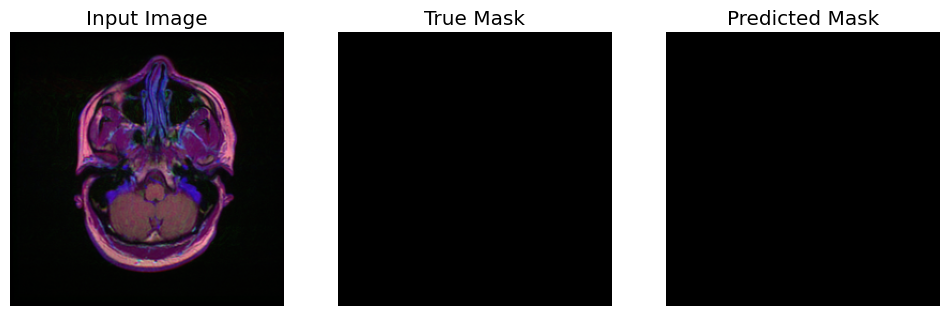

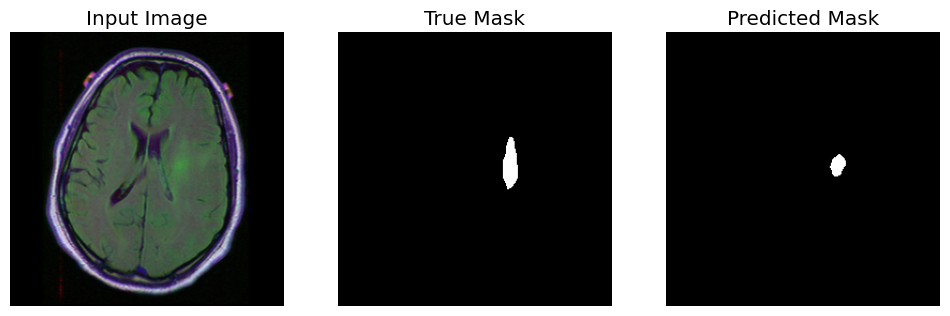

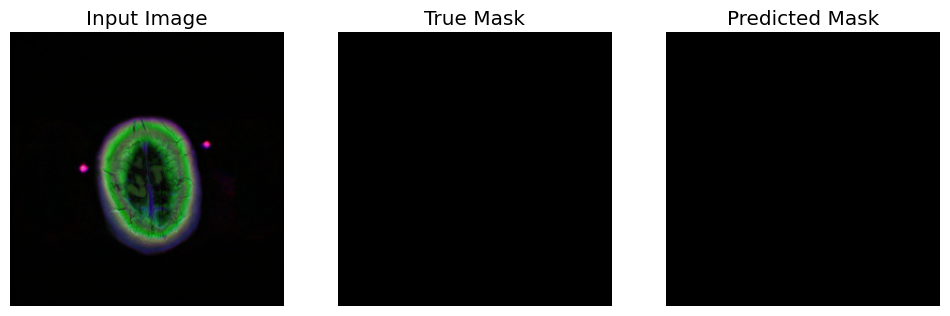

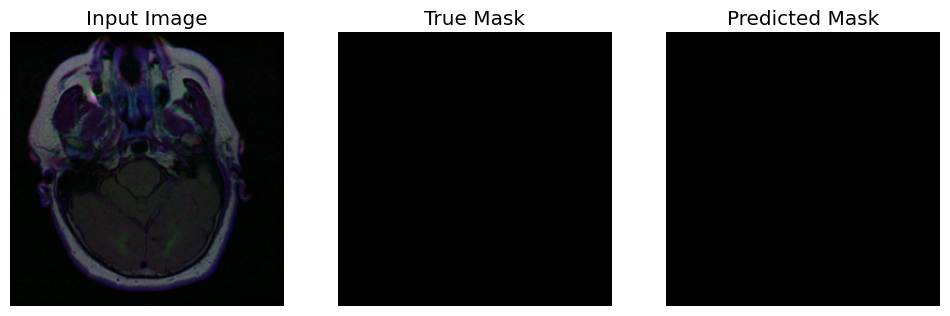

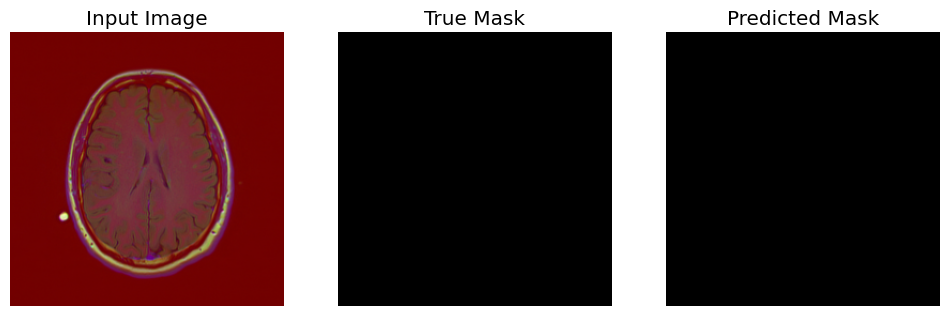

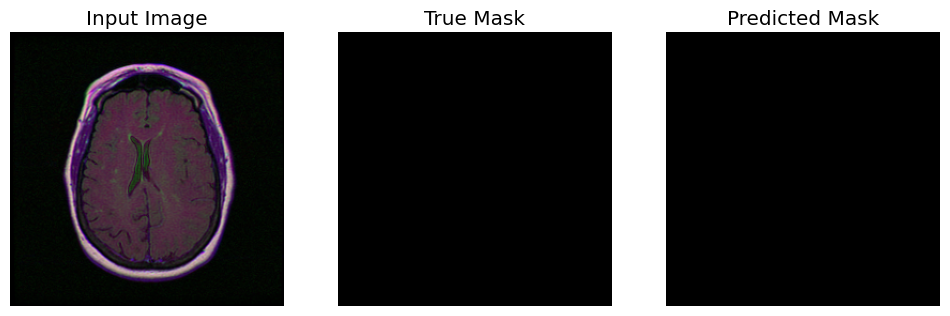

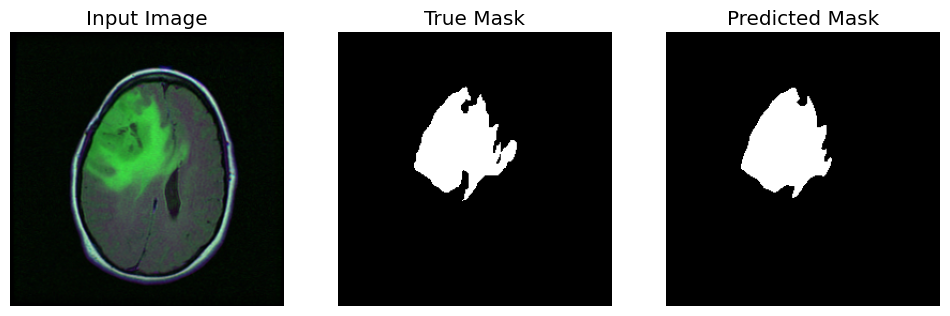

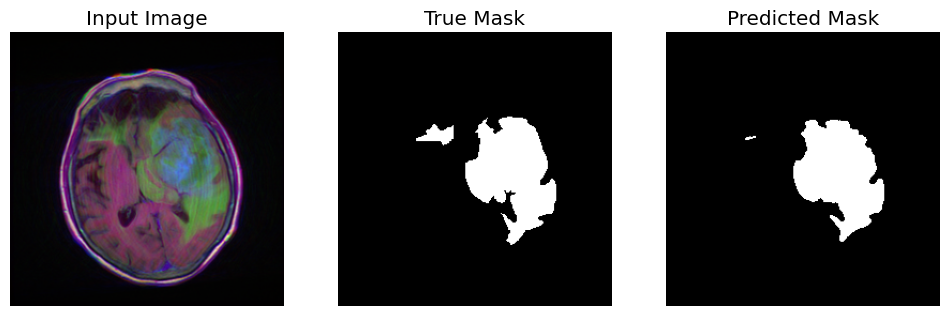

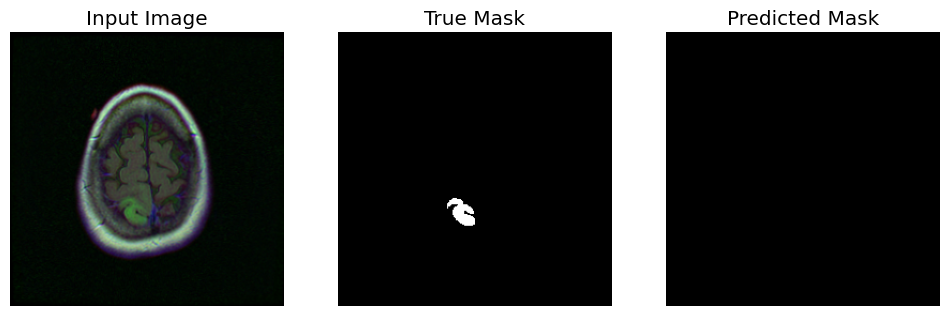

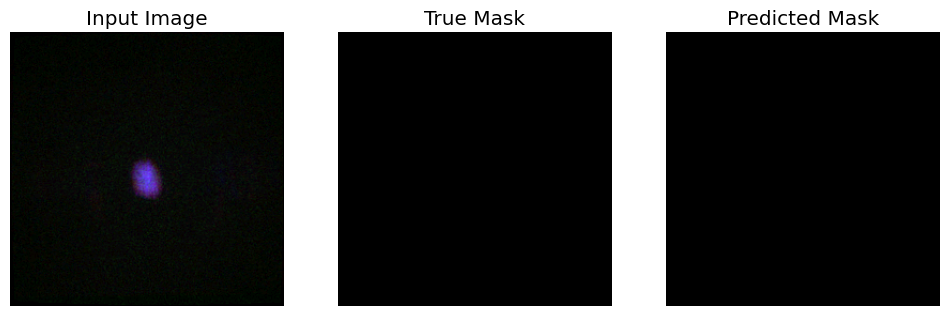

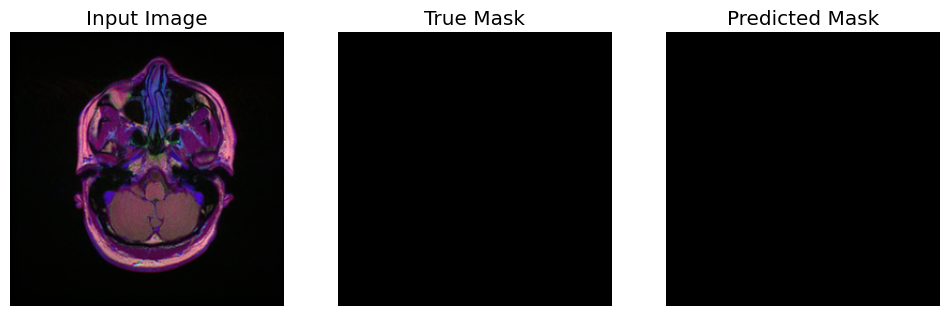

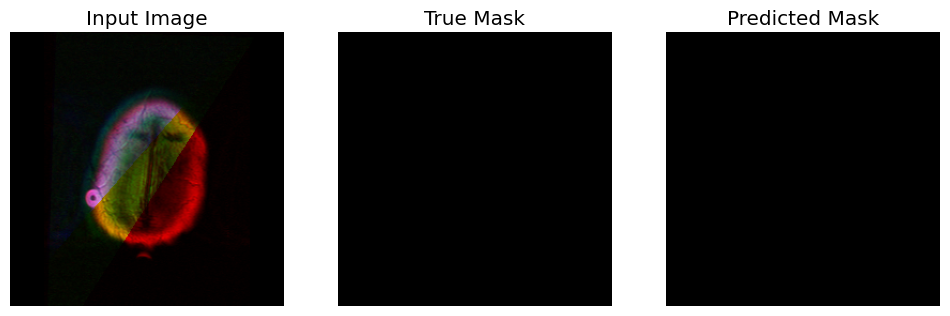

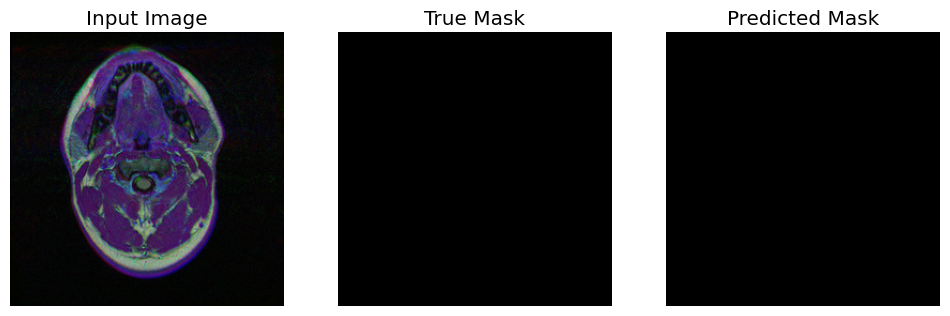

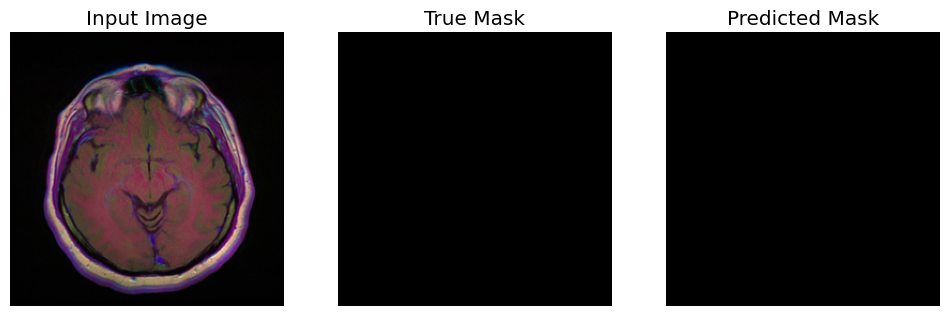

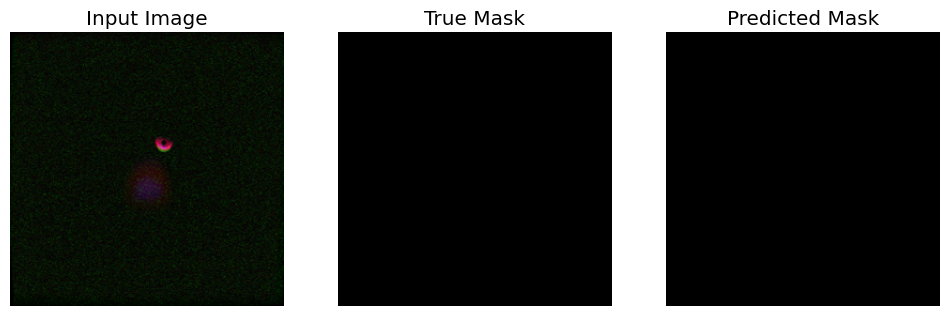

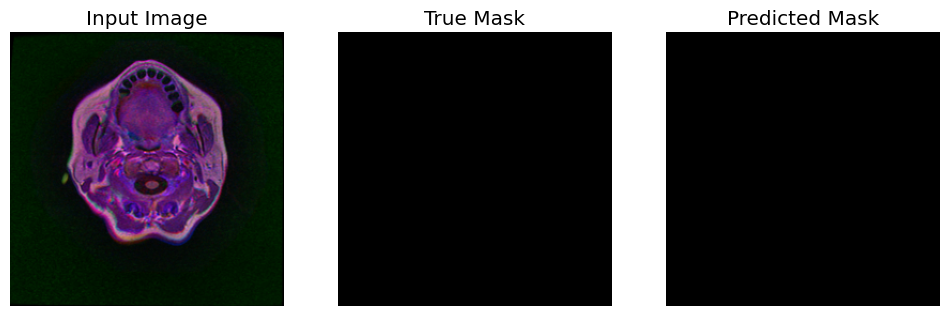

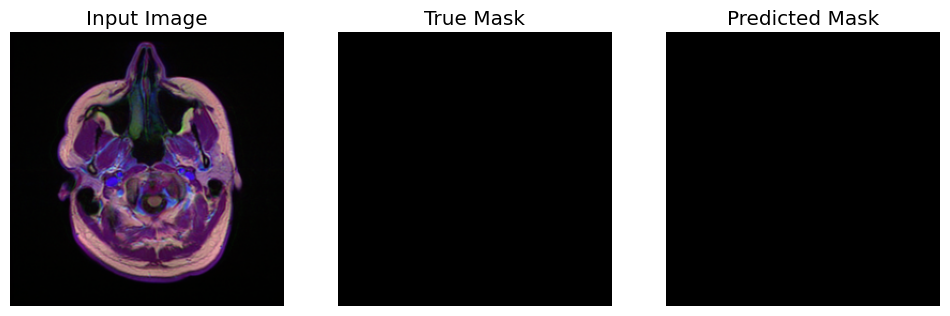

In [10]:
device = "cuda"

# Initialize the model
model = UNet().to(device)

# Load the saved weights (replace with your actual path)
model.load_state_dict(torch.load("best_unet.pth", map_location=device))

# Set model to evaluation mode
model.eval()

# Function to plot predictions
def plot_predictions(model, test_loader, device="cuda", num_samples=5, threshold=0.5):
    model.eval()
    images_shown = 0
    
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            preds = (outputs > threshold).float()
            
            imgs = imgs.cpu()
            masks = masks.cpu()
            preds = preds.cpu()
            
            for i in range(imgs.size(0)):
                if images_shown >= num_samples:
                    return
                
                fig, axs = plt.subplots(1, 3, figsize=(12, 4))
                
                # Original Image (scaled for visualization)
                img = imgs[i].permute(1, 2, 0).numpy()
                img_vis = (img - img.min()) / (img.max() - img.min() + 1e-8)  # Contrast stretch
                axs[0].imshow(img_vis)
                axs[0].set_title("Input Image")
                axs[0].axis('off')

                
                # Ground truth mask
                axs[1].imshow(masks[i][0], cmap='gray')
                axs[1].set_title("True Mask")
                axs[1].axis('off')
                
                # Predicted mask
                axs[2].imshow(preds[i][0], cmap='gray')
                axs[2].set_title("Predicted Mask")
                axs[2].axis('off')
                
                plt.show()
                images_shown += 1

                
plot_predictions(model, test_loader, device=device, num_samples=25)
